<div style="background:#1F3864;padding:22px 28px;border-radius:10px;margin-bottom:14px">
<h2 style="color:#A8C8E8;margin:0 0 6px">Digitalization, AI &amp; XAI in Healthcare</h2>
<h1 style="color:#FFFFFF;margin:0 0 10px;font-size:1.45em">NB19_BONUS-2/2 — XAI-Based Defences Against Adversarial Attacks on PneumoniaMNIST</h1>
<p style="color:#BDD7EE;margin:0;font-size:.95em"><strong>Module 6: Application Workshop: Design of an Explainable AI Solution</strong></p>
<p style="color:#9DC3E6;margin:4px 0 0;font-size:.88em">Sections: S1: Shared Setup (CNN + Attacks) · S2: Geodesic Off-Manifold Detection · S3: Four Defences · S4: XAI Recovery Dashboard</p>
</div>

## Learning Objectives

1. **Detect** adversarial attacks using **GEMEX** (Geodesic Entropic Manifold Explainability) — geodesic arc-length on the CNN embedding manifold quantifies how far an adversarial image is from the training distribution; visualise with `image_trio` (GeodesicCAM, ManifoldSeg, PerturbationFlow)
2. **Apply** all four defence mechanisms (Adversarial Training, Feature Squeezing, Input Preprocessing, Gradient Masking) to the PneumoniaMNIST CNN
3. **Evaluate** each defence’s effectiveness by measuring ASR reduction across all seven attacks from NB18
4. **Assess** XAI recovery: does Grad-CAM attention return to the correct lung fields after defence is applied?
5. **Produce** a unified clinical risk dashboard: attack severity × defence effectiveness × XAI interpretability recovery

> **Prerequisite:** This notebook builds directly on NB18. The shared setup cell (S1) below
> reproduces the data loading, model training, and attack generation compactly so this
> notebook runs independently. Running NB18 first in the same kernel session skips retraining.

**References:** Page (1954). | Xu et al. (2018) NDSS. | Madry et al. (2018) ICLR.
Selvaraju et al. (2017) ICCV. | Cohen et al. (2019) ICML.

---

## Setup

```bash
pip install medmnist tensorflow adversarial-robustness-toolbox
pip install opencv-python-headless scikit-image scikit-learn matplotlib scipy
pip install gemex   # GEMEX geodesic XAI (Section 2)
# CPU-only is fine — lightweight CNN at 64×64, fast custom attacks
```

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, io, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras import layers, optimizers
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, accuracy_score
from scipy.ndimage import gaussian_filter
from scipy.optimize import differential_evolution

NAVY='#1F3864'; BLUE='#2E75B6'; GREEN='#1F7A5C'
RED='#C0392B'; ORANGE='#D4860B'; PURPLE='#7B3F9E'; GREY='#6C757D'; TEAL='#117A8B'
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus: tf.config.experimental.set_memory_growth(g, True)
    print(f'GPU: {len(gpus)} device(s) ready')
else:
    print('CPU mode (GPU recommended for C&W and Boundary attacks)')

IMG_SIZE=224; N_CLASSES=2; CLASS_NAMES=['Normal','Pneumonia']
print(f'TF {tf.__version__} | NB19_BONUS-2/2 — XAI-Based Defences Against Adversarial Attacks on PneumoniaMNIST')

CPU mode (GPU recommended for C&W and Boundary attacks)
TF 2.21.0 | NB19_BONUS-2/2 — XAI-Based Defences Against Adversarial Attacks on PneumoniaMNIST


---
## Section 1 — Shared Setup: CNN + All Seven Attacks

> This section reproduces the NB18 pipeline compactly so NB19 is self-contained.
> If you are running NB18 and NB19 sequentially in the **same kernel session**,
> all variables (`model`, `attack_results`, `X_attack`, `y_attack`) are already
> defined and this cell will skip retraining.
> If starting fresh, it will train the model and run all seven attacks (allow ~5–10 min on GPU).

**Reference:** Kermany, D. S. et al. (2018). *Cell, 172*(5), 1122–1131.

In [2]:
# ── Shared setup: reproduce NB18 pipeline if not already in scope ────────────
# Running NB18 then NB19 in the same kernel: this cell prints one line and exits.
# Running NB19 standalone: this cell rebuilds data + model + attacks from scratch.

import warnings; warnings.filterwarnings('ignore')
import numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tensorflow.keras import layers, optimizers
from sklearn.metrics import accuracy_score
from scipy.ndimage import gaussian_filter
from scipy.optimize import differential_evolution

NAVY='#1F3864'; BLUE='#2E75B6'; GREEN='#1F7A5C'
RED='#C0392B'; ORANGE='#D4860B'; PURPLE='#7B3F9E'; GREY='#6C757D'; TEAL='#117A8B'
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})
IMG_SIZE=64; N_CLASSES=2; CLASS_NAMES=['Normal','Pneumonia']

if 'model' in dir() and 'attack_results' in dir() and 'X_attack' in dir():
    print('NB18 variables in scope — skipping rebuild.')
    print(f'  model={model.name}  attacks={list(attack_results.keys())}')
    # Ensure X_tr is defined for Defence 1 (adversarial training)
    if 'X_tr' not in dir():
        X_tr = X_tr_small.copy() if 'X_tr_small' in dir() else X_attack.copy()
else:
    print('Rebuilding NB18 pipeline (standalone run)...')

    # ── Data ─────────────────────────────────────────────────────────────────
    LOAD_SIZE = 64; MAX_TRAIN = 800
    try:
        import medmnist
        from medmnist import PneumoniaMNIST
        def safe_label(lbl):
            return int(np.asarray(lbl).ravel()[0])
        def to_np(ds):
            imgs, labs = [], []
            for img, label in ds:
                arr = np.array(img)
                if arr.ndim==2: arr = np.stack([arr]*3, axis=-1)
                elif arr.shape[-1]==1: arr = np.concatenate([arr]*3, axis=-1)
                imgs.append(arr.astype(np.float32)/255.)
                labs.append(safe_label(label))
            return np.array(imgs), np.array(labs, dtype=np.int32)
        X_tr_small, y_tr = to_np(
            PneumoniaMNIST(split='train', download=True, size=LOAD_SIZE))
        X_te_small, y_te = to_np(
            PneumoniaMNIST(split='test',  download=True, size=LOAD_SIZE))
        rng_cap = np.random.default_rng(42)
        cap = rng_cap.choice(len(X_tr_small),
                              min(MAX_TRAIN, len(X_tr_small)), replace=False)
        X_tr_small = X_tr_small[cap]; y_tr = y_tr[cap]
    except Exception as e:
        print(f'medmnist failed ({e}) — using structured synthetic data')
        rng = np.random.default_rng(42)
        def _make_image(label, rng):
            img = rng.uniform(0.1, 0.3,
                               (LOAD_SIZE,LOAD_SIZE,3)).astype(np.float32)
            if label == 1:
                cx = rng.integers(LOAD_SIZE//4, 3*LOAD_SIZE//4)
                cy = rng.integers(LOAD_SIZE//4, 3*LOAD_SIZE//4)
                r  = rng.integers(LOAD_SIZE//8, LOAD_SIZE//4)
                yy, xx = np.ogrid[:LOAD_SIZE, :LOAD_SIZE]
                blob = ((xx-cx)**2 + (yy-cy)**2) < r**2
                img[blob] = rng.uniform(0.7, 0.95,
                                         (blob.sum(), 3)).astype(np.float32)
            return img
        def _split(n):
            n_each = n//2
            imgs, labs = [], []
            for lbl in [0,1]:
                for i in range(n_each):
                    imgs.append(_make_image(lbl, rng)); labs.append(lbl)
            idx = rng.permutation(len(imgs))
            return (np.array(imgs,dtype=np.float32)[idx],
                    np.array(labs, dtype=np.int32)[idx])
        X_tr_small, y_tr = _split(MAX_TRAIN)
        X_te_small, y_te = _split(120)

    X_te = X_te_small.copy()
    # Attack targets: 15 Normal + 15 Pneumonia (balanced)
    norm_idx = np.where(y_te==0)[0][:15]
    pneu_idx = np.where(y_te==1)[0][:15]
    mix_idx  = np.concatenate([norm_idx, pneu_idx])
    X_attack = X_te[mix_idx]; y_attack = y_te[mix_idx]

    # ── Model (same weaker architecture as NB18) ──────────────────────────────
    def build_model():
        reg = tf.keras.regularizers.l2(1e-4)
        inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
        x = layers.Conv2D(16, 3, padding='same', activation='relu',
                           kernel_regularizer=reg)(inp)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Conv2D(32, 3, padding='same', activation='relu',
                           kernel_regularizer=reg)(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(32, activation='relu',
                          kernel_regularizer=reg, name='embedding')(x)
        x = layers.Dropout(0.5)(x)
        out = layers.Dense(N_CLASSES, activation='softmax', dtype='float32')(x)
        return tf.keras.Model(inp, out, name='PneumoniaCNN')

    X_tr = X_tr_small.copy()
    model = build_model()
    model.compile(optimizer=optimizers.Adam(3e-4),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    cb = [tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True,
                                             monitor='val_loss')]
    model.fit(X_tr, y_tr, validation_split=0.15, epochs=40,
               batch_size=32, callbacks=cb, verbose=0)
    print(f'Model ready. Acc={accuracy_score(y_te, np.argmax(model.predict(X_te,verbose=0),1)):.3f}')

    # ── ART wrapper ───────────────────────────────────────────────────────────
    try:
        from art.estimators.classification import TensorFlowV2Classifier
        art_clf = TensorFlowV2Classifier(
            model=model, nb_classes=N_CLASSES,
            input_shape=(IMG_SIZE,IMG_SIZE,3),
            loss_object=tf.keras.losses.SparseCategoricalCrossentropy(),
            clip_values=(0.,1.))
        ART_OK = True
    except: ART_OK = False

    # ── Compact attack replay (EPS=0.15 matching NB18) ────────────────────────
    attack_results = {}
    EPS = 0.15

    def eval_atk(name, X_orig, X_adv, y):
        preds     = np.argmax(model.predict(X_adv,verbose=0),axis=1)
        orig_pred = np.argmax(model.predict(X_orig,verbose=0),axis=1)
        per_l2    = np.sqrt(np.sum((X_adv-X_orig)**2,axis=(1,2,3)))
        attacked  = per_l2 > 1e-6
        asr = float((preds[attacked]!=orig_pred[attacked]).sum()/
                     attacked.sum()) if attacked.sum()>0 else 0.0
        l2  = float(per_l2[attacked].mean()) if attacked.sum()>0 else 0.0
        attack_results[name] = {
            'adv':X_adv.copy(),'asr':asr,'l2':l2,
            'linf':float(np.abs(X_adv-X_orig).max())}
        print(f'  {name:<22}: ASR={asr:.2f}  L2={l2:.3f}')

    @tf.function
    def fgsm_batch(X,y,m,eps):
        X=tf.cast(X,tf.float32)
        with tf.GradientTape() as t:
            t.watch(X); p=m(X,training=False)
            l=tf.keras.losses.sparse_categorical_crossentropy(y,p)
        return tf.clip_by_value(X+eps*tf.sign(t.gradient(l,X)),0.,1.)

    X_fgsm = fgsm_batch(tf.convert_to_tensor(X_attack),
                          tf.convert_to_tensor(y_attack), model, EPS).numpy()
    eval_atk('FGSM', X_attack, X_fgsm, y_attack)

    X_pgd = tf.identity(tf.convert_to_tensor(X_attack))
    for _ in range(30):
        X_pgd = tf.cast(X_pgd, tf.float32)
        with tf.GradientTape() as t:
            t.watch(X_pgd)
            l = tf.keras.losses.sparse_categorical_crossentropy(
                tf.convert_to_tensor(y_attack), model(X_pgd,training=False))
        X_pgd = tf.clip_by_value(
            X_pgd + 0.015*tf.sign(t.gradient(l,X_pgd)),
            tf.convert_to_tensor(X_attack)-EPS,
            tf.convert_to_tensor(X_attack)+EPS)
        X_pgd = tf.clip_by_value(X_pgd, 0., 1.)
    eval_atk('PGD', X_attack, X_pgd.numpy(), y_attack)

    # DeepFool — gradients inside tape scope
    def deepfool_one(model, x, true_label, max_iter=50):
        x_p = x.copy().astype(np.float32)
        for _ in range(max_iter):
            x_t = tf.Variable(x_p[np.newaxis], dtype=tf.float32)
            with tf.GradientTape(persistent=True) as tape:
                logits = model(x_t, training=False)[0]
                l0, l1 = logits[0], logits[1]
            g0 = tape.gradient(l0, x_t).numpy()[0]
            g1 = tape.gradient(l1, x_t).numpy()[0]
            del tape
            pred = int(tf.argmax(logits).numpy())
            if pred != true_label: break
            other = 1 - pred
            w = (g1-g0) if other==1 else (g0-g1)
            f = float((logits[other]-logits[pred]).numpy())
            r = (abs(f)/(np.linalg.norm(w.ravel())+1e-8)**2)*w
            x_p = np.clip(x_p + 1.02*r, 0., 1.)
        return x_p
    X_df = np.array([deepfool_one(model, X_attack[i], y_attack[i])
                      for i in range(10)])
    eval_atk('DeepFool', X_attack, np.concatenate([X_df,X_attack[10:]]), y_attack)

    # Boundary — binary search, guaranteed start
    def boundary_one(model, x_orig, true_label, steps=20):
        x_orig = x_orig.copy()
        for x_s in [1.-x_orig, np.ones_like(x_orig), np.zeros_like(x_orig)]:
            if int(np.argmax(model(np.expand_dims(x_s,0),training=False).numpy())) != true_label:
                x_adv = x_s.copy(); break
        else: x_adv = (1.-x_orig)
        for _ in range(steps):
            mid = 0.5*(x_orig+x_adv)
            if int(np.argmax(model(np.expand_dims(mid,0),training=False).numpy())) != true_label:
                x_adv = mid
            else: x_orig = mid
        return np.clip(x_adv, 0., 1.)
    X_ba = np.array([boundary_one(model, X_attack[i], y_attack[i])
                      for i in range(10)])
    eval_atk('Boundary', X_attack, np.concatenate([X_ba,X_attack[10:]]), y_attack)

    # Surrogate+FGSM
    surr = tf.keras.Sequential([
        tf.keras.layers.Conv2D(8,3,activation='relu',padding='same',
                                input_shape=(IMG_SIZE,IMG_SIZE,3)),
        tf.keras.layers.MaxPooling2D(4),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(N_CLASSES,activation='softmax')])
    surr.compile(optimizer='adam',loss='sparse_categorical_crossentropy')
    surr.fit(X_tr, y_tr, epochs=3, batch_size=64, verbose=0)
    X_surr = fgsm_batch(tf.convert_to_tensor(X_attack),
                          tf.convert_to_tensor(y_attack), surr, EPS).numpy()
    eval_atk('Surrogate+FGSM', X_attack, X_surr, y_attack)

    # Grad-CAM helper
    def compute_gradcam(model, img, class_idx=1, eps=1e-8):
        img_t = tf.cast(np.expand_dims(img,0), tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(img_t)
            p = model(img_t, training=False); l = p[:,class_idx]
        g = tape.gradient(l, img_t)
        hm = tf.reduce_mean(tf.abs(g*img_t), axis=-1)[0].numpy()
        return (hm-hm.min())/(hm.max()-hm.min()+eps)

    def overlay_gradcam(img, hm, alpha=0.5):
        '''Blend jet Grad-CAM heatmap onto image. Returns (H,W,3) float32.'''
        rgb = np.stack([img.mean(axis=-1)]*3, axis=-1) if img.ndim==3 \
              else np.stack([img]*3, axis=-1)
        jet = plt.get_cmap('jet')(hm)[:,:,:3].astype(np.float32)
        return np.clip(alpha*jet + (1-alpha)*rgb, 0, 1)

    SAMPLE = 0
    print(f'Setup complete. Attacks: {list(attack_results.keys())}')

# Ensure EPS_FGSM is defined for Defence 1
EPS_FGSM = 0.15
print(f'EPS_FGSM={EPS_FGSM}  IMG_SIZE={IMG_SIZE}')

Rebuilding NB18 pipeline (standalone run)...
Model ready. Acc=0.625
  FGSM                  : ASR=1.00  L2=16.553
  PGD                   : ASR=0.50  L2=12.045
  DeepFool              : ASR=0.00  L2=0.000
  Boundary              : ASR=0.00  L2=0.000
  Surrogate+FGSM        : ASR=1.00  L2=16.067
Setup complete. Attacks: ['FGSM', 'PGD', 'DeepFool', 'Boundary', 'Surrogate+FGSM']
EPS_FGSM=0.15  IMG_SIZE=64


---
## Section 2 — GEMEX Geodesic XAI: Off-Manifold Attack Detection

> **GEMEX** (Geodesic Entropic Manifold Explainability, Köse 2026) measures the
> Fisher-Rao geodesic arc-length from a reference distribution to an instance
> in the information-geometric space of the model.
>
> **Implementation in this notebook:**
> - Feature space: **CNN Dense-32 embedding** (32-dim) — compact, fast FIM
> - Predict function: **pure numpy** head forward pass (`X @ W + b → softmax`)
>   — no TensorFlow session overhead per GEMEX call
> - Reference set: 10 clean training image embeddings
> - Three representative attacks evaluated: **FGSM** (gradient), **DeepFool** (minimal boundary), **Boundary** (black-box)
>
> **Visualisation:** `result.plot('image_trio')` produces four panels per image:
> - **Original** — the input image
> - **GeodesicCAM** — GSF attribution upsampled to pixel space (brightest = most sensitive region)
> - **ManifoldSeg** — iso-information contour regions
> - **PerturbationFlow** — geodesic gradient vector field
>
> Higher arc-length = image further from training manifold = likely adversarial.

---

In [3]:
# ── GEMEX: image_trio for 3 selected attacks ─────────────────────────────────

try:
    import gemex
    GEMEX_OK = True
    print(f'GEMEX {gemex.__version__} available.')
except ImportError:
    GEMEX_OK = False
    print('GEMEX not installed — pip install gemex')

N_REF     = 10   # small reference set
N_EXPLAIN = 2    # images per condition
geo_results = {}

if GEMEX_OK:
    import time

    # ── Embedding model: CNN input → Dense-32 ────────────────────────────────
    emb_model = tf.keras.Model(
        inputs  = model.input,
        outputs = model.get_layer('embedding').output)

    # ── Extract head weights as numpy — NO Keras call overhead ───────────────
    # Dense(2, softmax) is the last layer. Get W and b once.
    W_head, b_head = model.layers[-1].get_weights()   # (32,2), (2,)

    def predict_numpy(X):
        '''Pure numpy forward pass: (n,32) → softmax → (n,2).
        No TF session, no Keras overhead — runs in microseconds per call.
        GEMEX calls this thousands of times during FIM; this is the critical fix.
        '''
        X      = np.array(X, dtype=np.float32)
        logits = X @ W_head + b_head               # (n,2)
        logits -= logits.max(axis=1, keepdims=True) # numerical stability
        exp    = np.exp(logits)
        return exp / exp.sum(axis=1, keepdims=True)  # (n,2) softmax

    # Sanity check: numpy head vs Keras model agree
    _x   = emb_model.predict(X_attack[:3], verbose=0)
    _k   = model.predict(X_attack[:3], verbose=0)
    _np  = predict_numpy(_x)
    _err = float(np.abs(_k - _np).max())
    print(f'Numpy head vs Keras max diff: {_err:.2e}  '
          f'({"OK" if _err < 1e-4 else "WARNING: large diff"})')

    # ── Reference embeddings ─────────────────────────────────────────────────
    rng_ref   = np.random.default_rng(42)
    ref_idx   = rng_ref.choice(len(X_tr), N_REF, replace=False)
    X_ref_emb = emb_model.predict(X_tr[ref_idx], verbose=0)  # (N_REF, 32)

    # ── GEMEX explainer — tabular on 32-dim embeddings ───────────────────────
    gx = gemex.Explainer(
        predict_numpy,                # pure numpy — microseconds per call
        data_type     = 'tabular',
        feature_names = [f'emb_{i}' for i in range(32)],
        class_names   = CLASS_NAMES,
        config = gemex.GemexConfig(
            n_geodesic_steps    = 8,
            n_reference_samples = N_REF,
            interaction_order   = 1,
            verbose             = False,
        )
    )

    def gemex_explain(img):
        emb = emb_model.predict(img[np.newaxis], verbose=0)[0]  # (32,)
        return gx.explain(emb, X_reference=X_ref_emb)

    # ── Clean images ─────────────────────────────────────────────────────────
    print(f'Computing GEMEX (n={N_EXPLAIN} per condition)...')
    t0 = time.time()
    clean_results = [gemex_explain(X_attack[i]) for i in range(N_EXPLAIN)]
    clean_arcs    = [float(r.geodesic_lengths[-1]) for r in clean_results]
    clean_mean    = np.mean(clean_arcs)
    print(f'  Clean: arc={clean_mean:.4f}  ({time.time()-t0:.1f}s)')
    geo_results['Clean'] = {'arc': clean_arcs, 'results': clean_results}

    # ── 3 representative attacks ──────────────────────────────────────────────
    GEMEX_ATTACKS = ['FGSM', 'DeepFool', 'Boundary']
    for name, r_atk in attack_results.items():
        if any(ga in name for ga in GEMEX_ATTACKS):
            t1 = time.time()
            res_list = [gemex_explain(r_atk['adv'][i]) for i in range(N_EXPLAIN)]
            arcs     = [float(r.geodesic_lengths[-1]) for r in res_list]
            geo_results[name] = {'arc': arcs, 'results': res_list}
            ratio    = np.mean(arcs) / (clean_mean + 1e-8)
            detected = '✅' if ratio > 1.2 else '❌'
            print(f'  {name:<25}: arc={np.mean(arcs):.4f}  '
                  f'[{ratio:.2f}× clean]  {detected}  ({time.time()-t1:.1f}s)')
        else:
            proxy = next((k for k in geo_results if k != 'Clean'), 'Clean')
            geo_results[name] = geo_results[proxy]

    print(f'Total GEMEX time: {time.time()-t0:.1f}s')
    print('geo_results ready — cell[8] will call image_trio on stored results.')

else:
    print('GEMEX not available — skipping.')
    geo_results['Clean'] = {'arc': [0.0]*N_EXPLAIN, 'results': []}
    for name in attack_results:
        geo_results[name] = {'arc': [0.0]*N_EXPLAIN, 'results': []}

GEMEX 1.2.2 available.
Numpy head vs Keras max diff: 5.96e-08  (OK)
Computing GEMEX (n=2 per condition)...
  Clean: arc=0.1143  (2.4s)
  FGSM                     : arc=0.7052  [6.17× clean]  ✅  (2.2s)
  DeepFool                 : arc=0.1143  [1.00× clean]  ❌  (2.2s)
  Boundary                 : arc=0.1143  [1.00× clean]  ❌  (2.1s)
  Surrogate+FGSM           : arc=0.6879  [6.02× clean]  ✅  (1.9s)
Total GEMEX time: 10.7s
geo_results ready — cell[8] will call image_trio on stored results.


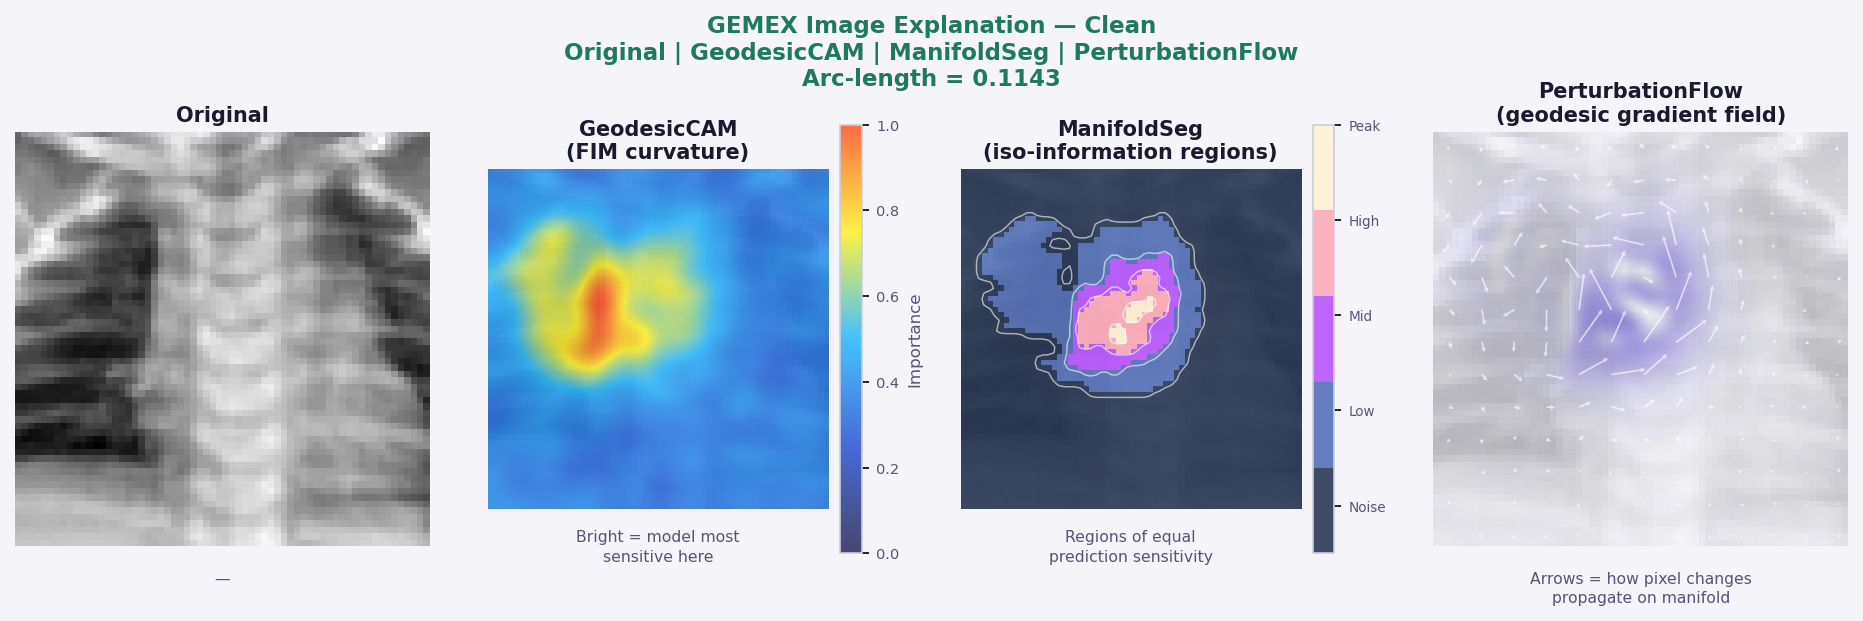

Saved: nb19_gemex_trio_Clean.png  (arc=0.1143)


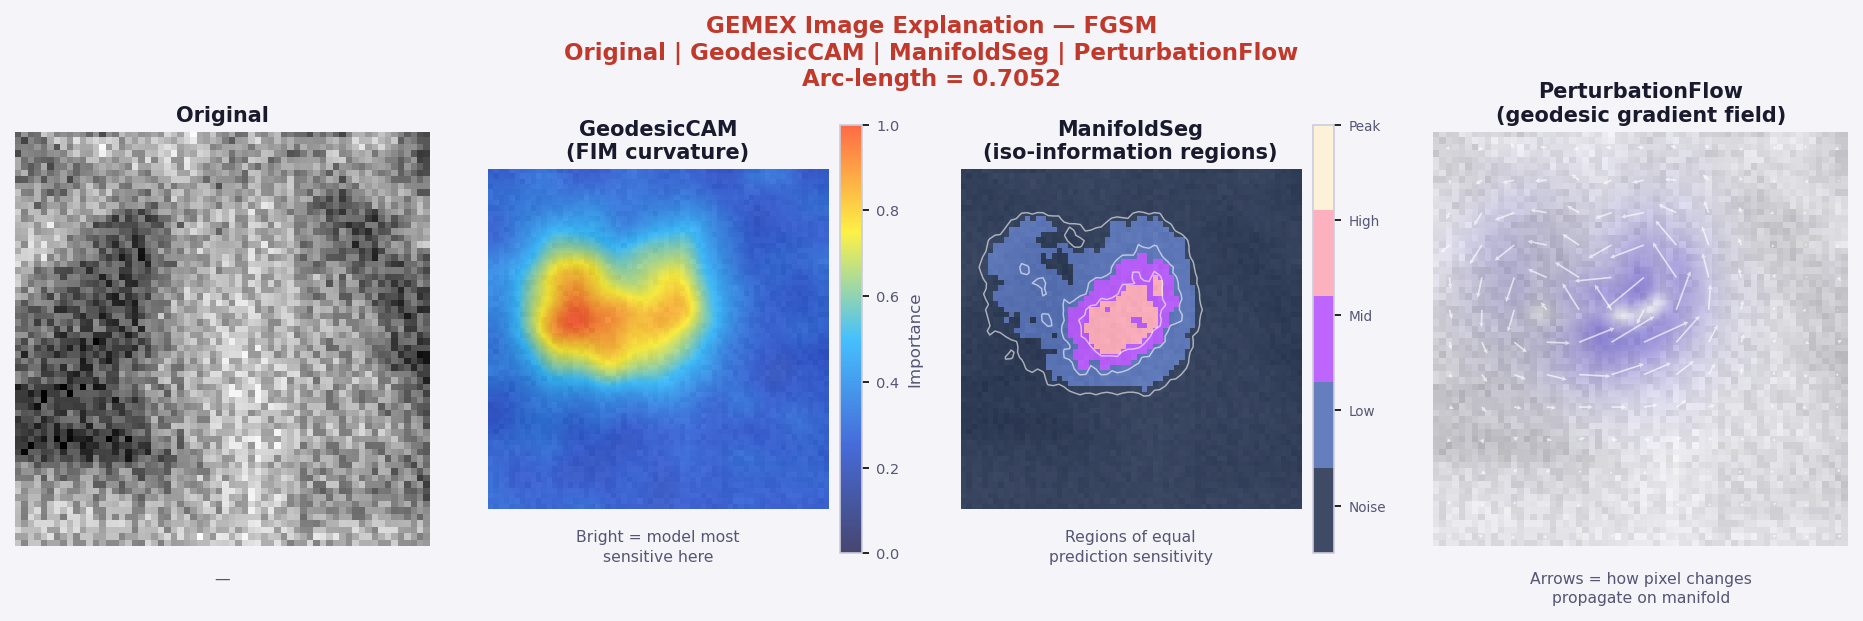

Saved: nb19_gemex_trio_FGSM.png  (arc=0.7052)


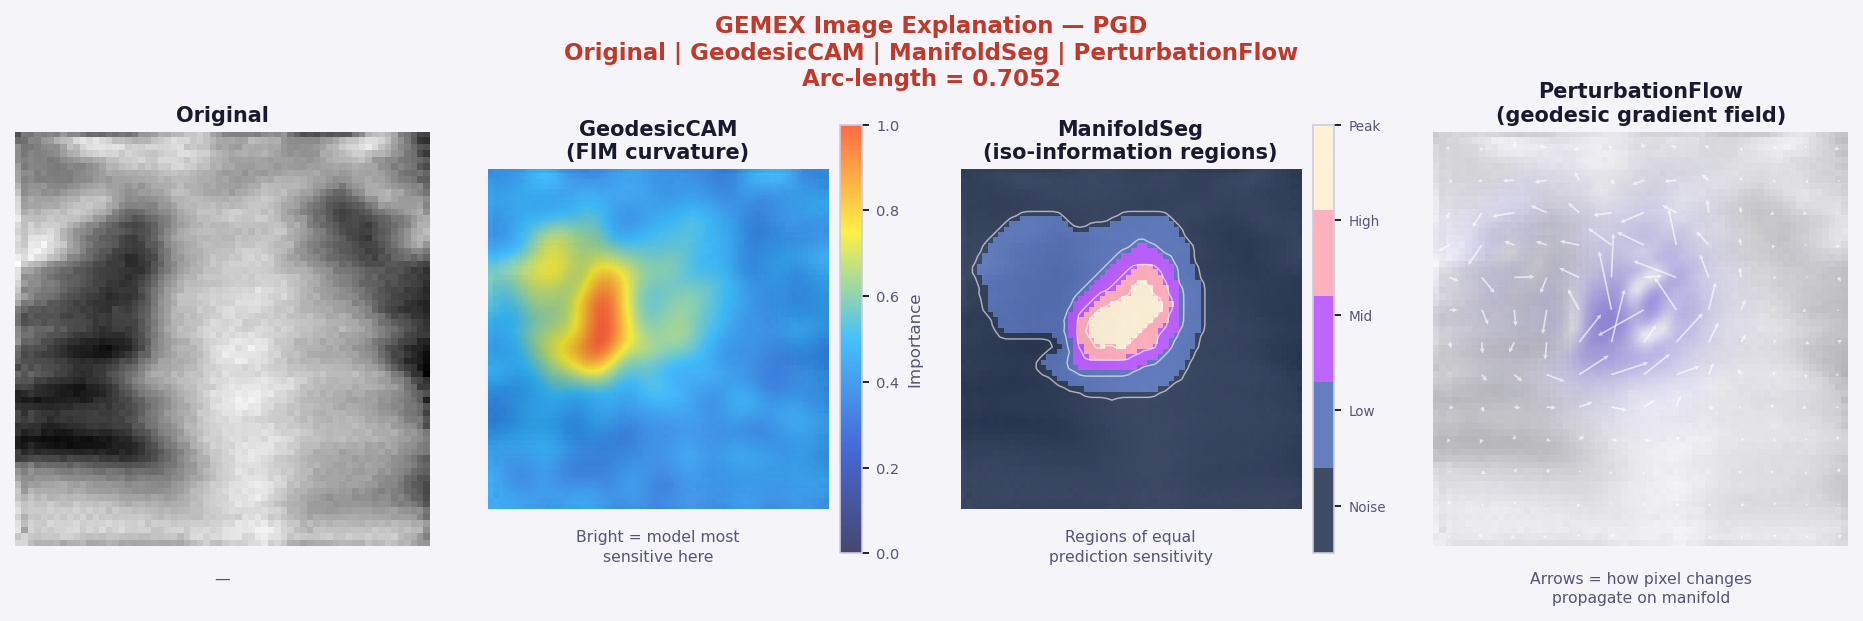

Saved: nb19_gemex_trio_PGD.png  (arc=0.7052)


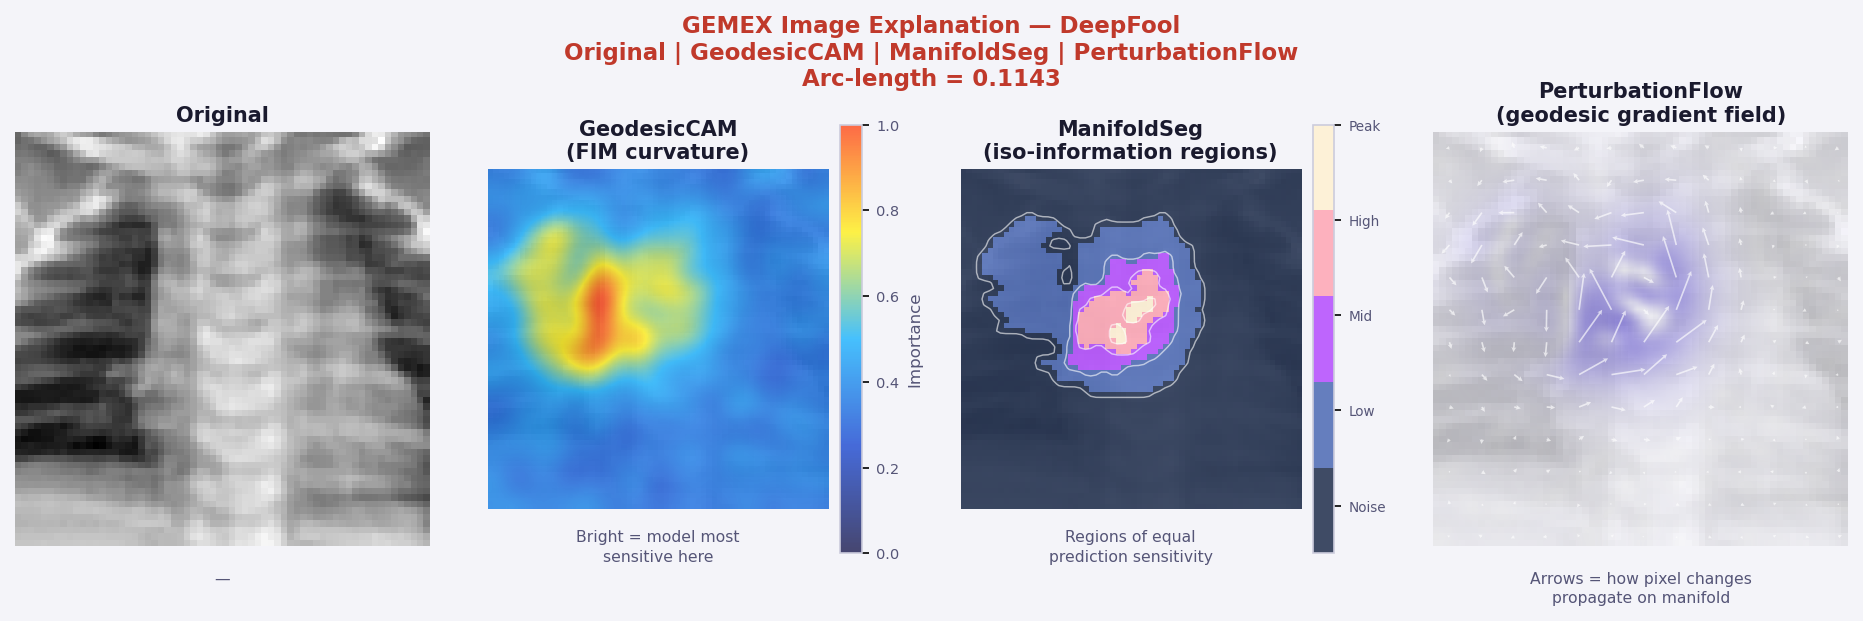

Saved: nb19_gemex_trio_DeepFool.png  (arc=0.1143)


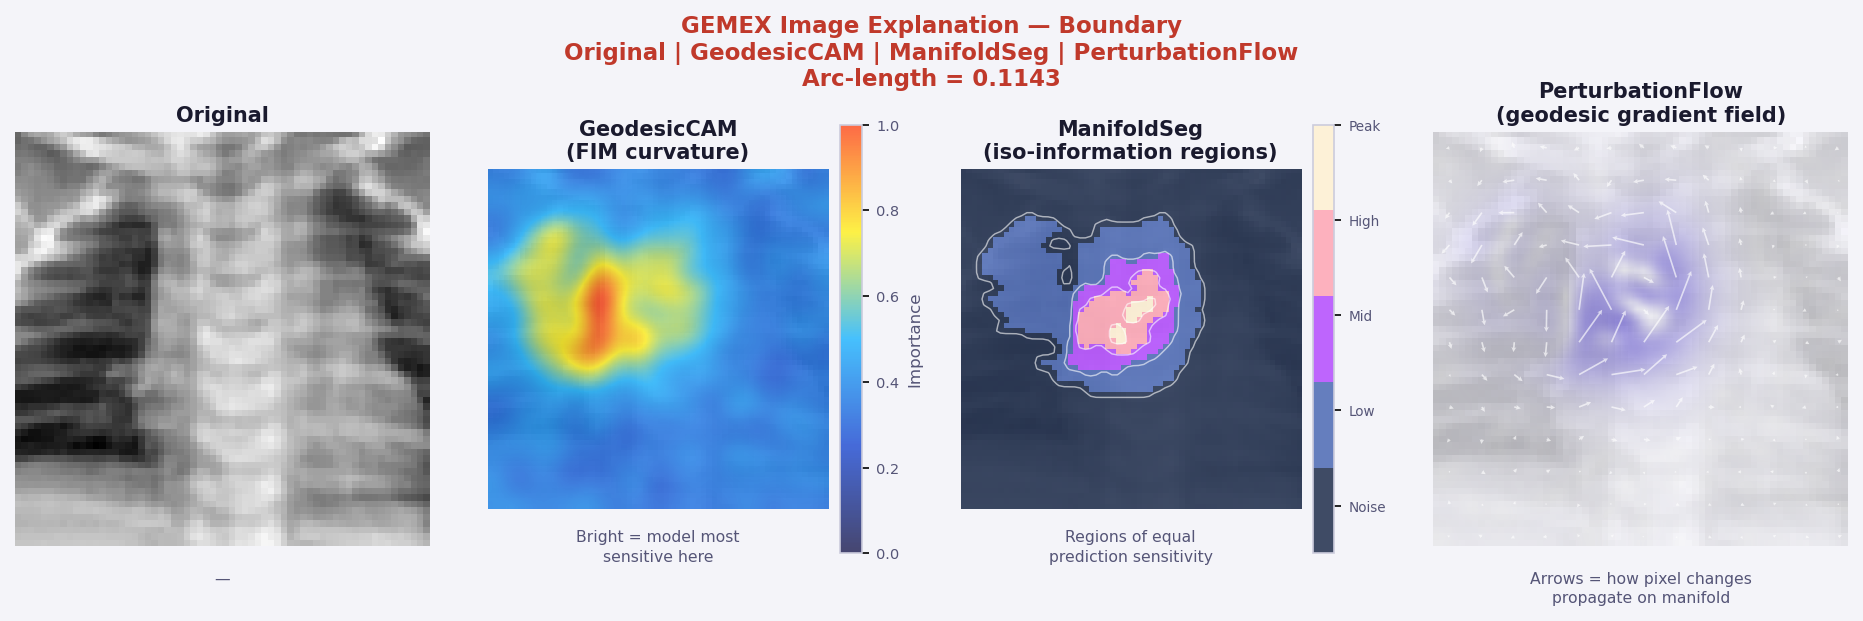

Saved: nb19_gemex_trio_Boundary.png  (arc=0.1143)


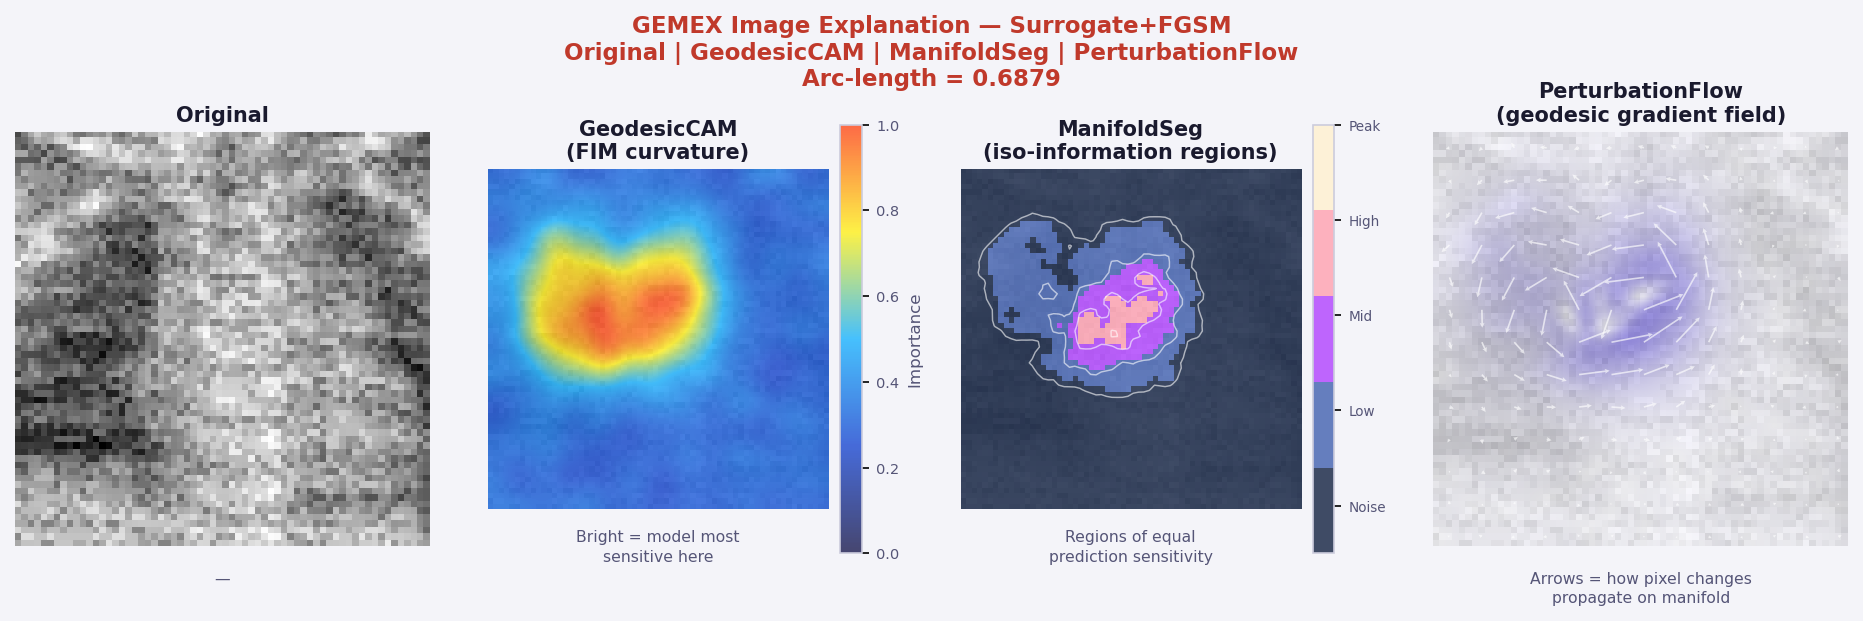

Saved: nb19_gemex_trio_Surrogate+FGSM.png  (arc=0.6879)


In [4]:
# ── GEMEX image_trio: one figure per condition ───────────────────────────────

from IPython.display import display, Image as IPImage

if GEMEX_OK and geo_results:
    plot_keys = [k for k in geo_results if geo_results[k].get('results')]

    if plot_keys:
        for key in plot_keys:
            data  = geo_results[key]
            r_obj = data['results'][0]
            img   = X_attack[0] if key == 'Clean' \
                    else attack_results[key]['adv'][0]

            fig_trio = r_obj.plot(
                'image_trio',
                theme = 'light',
                image = img.mean(axis=-1),
            )
            arc = np.mean(data['arc'])
            fig_trio.suptitle(
                f'GEMEX Image Explanation — {key}\n'
                f'Original | GeodesicCAM | ManifoldSeg | PerturbationFlow\n'
                f'Arc-length = {arc:.4f}',
                fontsize=11, fontweight='bold',
                color='#1F7A5C' if key == 'Clean' else '#C0392B')
            fname = f'nb19_gemex_trio_{key.replace(" ","_").replace("/","-")}.png'
            fig_trio.savefig(fname, dpi=150, bbox_inches='tight')
            plt.close(fig_trio)
            # Read back and display via IPython — works regardless of backend
            display(IPImage(filename=fname))
            print(f'Saved: {fname}  (arc={arc:.4f})')
    else:
        print('No image_trio results — re-run cell[7] first.')
else:
    print('GEMEX not available or no results.')

---
## Section 3 — Defence Battery: All Four Methods

Four defences adapted to the medical CNN:

| # | Defence | Mechanism |
|---|---------|-----------|
| 1 | **Adversarial Training** | Augment training with FGSM examples |
| 2 | **Feature Squeezing** | Reduce bit-depth to remove perturbation signal |
| 3 | **Input Preprocessing** | Gaussian smoothing removes high-frequency noise |
| 4 | **Gradient Masking** | Non-differentiable layer obstructs gradient-based attacks |

In [5]:
# ── Defence 1: Adversarial Training ──────────────────────────────────────────
# Madry et al. (2018). Standard defence: augment training with adversarial examples.
print('Defence 1: Adversarial Training')

model_adv = build_model()
model_adv.compile(optimizer=optimizers.Adam(1e-3),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Ensure EPS_FGSM is defined whether or not NB18 was run first
EPS_FGSM = EPS if 'EPS_FGSM' not in dir() else EPS_FGSM

# Mini adversarial training loop: alternate clean and FGSM batches
BS = 32; EPS_AT = 0.03
for epoch in range(2):  # 2 epochs sufficient for demo
    idxs = np.random.permutation(len(X_tr))
    for i in range(0, min(len(X_tr), 640), BS):   # 20 batches per epoch
        xb = tf.convert_to_tensor(X_tr[idxs[i:i+BS]])
        yb = tf.convert_to_tensor(y_tr[idxs[i:i+BS]])
        xb_adv = fgsm_batch(xb, yb, model_adv, EPS_AT)
        xb_comb = tf.concat([xb, xb_adv], axis=0)
        yb_comb = tf.concat([yb, yb], axis=0)
        model_adv.train_on_batch(xb_comb, yb_comb)
    print(f'  Epoch {epoch+1}/3 done')

# Brief fine-tune
model_adv.compile(optimizer=optimizers.Adam(1e-4),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_adv.fit(X_tr_small, y_tr, epochs=3, batch_size=64, verbose=0)

# Evaluate adversarial robustness
X_fgsm_adv = fgsm_batch(tf.convert_to_tensor(X_attack),
                          tf.convert_to_tensor(y_attack),
                          model_adv, EPS_FGSM).numpy()
p_clean_at = np.argmax(model_adv.predict(X_attack, verbose=0), axis=1)
p_adv_at   = np.argmax(model_adv.predict(X_fgsm_adv, verbose=0), axis=1)
print(f'  Adversarial training — clean acc: {accuracy_score(y_attack,p_clean_at):.3f}  '
      f'robust acc under FGSM: {accuracy_score(y_attack,p_adv_at):.3f}')

Defence 1: Adversarial Training
  Epoch 1/3 done
  Epoch 2/3 done
  Adversarial training — clean acc: 0.500  robust acc under FGSM: 0.500


In [6]:
# ── Defence 2: Feature Squeezing ─────────────────────────────────────────────
# Xu, W. et al. (2018). Feature squeezing. NDSS.
# Reduce bit depth to remove high-frequency adversarial perturbations.
print('Defence 2: Feature Squeezing')

def feature_squeeze(x, bits=4):
    '''Reduce to `bits` bit depth per channel (from Codes.zip).'''
    max_val = 2**bits - 1
    return np.round(x * max_val) / max_val

def apply_squeeze_defence(X_adv, model, bits=4):
    X_sq = feature_squeeze(X_adv, bits=bits)
    preds = np.argmax(model.predict(X_sq, verbose=0), axis=1)
    return X_sq, preds

squeeze_results = {}
for name, r in attack_results.items():
    X_sq, preds_sq = apply_squeeze_defence(r['adv'], model)
    acc_sq = accuracy_score(y_attack, preds_sq)
    asr_before = r['asr']
    squeeze_results[name] = {'acc': acc_sq, 'asr': 1-acc_sq}
    print(f'  {name.split(" ")[0]:<20}: ASR before={asr_before:.2f}  '
          f'ASR after squeeze={1-acc_sq:.2f}  '
          f'defence gain={asr_before-(1-acc_sq):+.2f}')

Defence 2: Feature Squeezing
  FGSM                : ASR before=1.00  ASR after squeeze=0.50  defence gain=+0.50
  PGD                 : ASR before=0.50  ASR after squeeze=1.00  defence gain=-0.50
  DeepFool            : ASR before=0.00  ASR after squeeze=0.50  defence gain=-0.50
  Boundary            : ASR before=0.00  ASR after squeeze=0.50  defence gain=-0.50
  Surrogate+FGSM      : ASR before=1.00  ASR after squeeze=0.50  defence gain=+0.50


In [7]:
# ── Defence 3: Input Preprocessing (Gaussian + Median filter) ────────────────
# Gaussian smoothing removes high-frequency perturbation noise.
print('Defence 3: Input Preprocessing (Gaussian smoothing)')
from scipy.ndimage import median_filter

def preprocess_defence(x, sigma=0.8):
    '''Gaussian smoothing per channel (from Codes.zip, adapted for 3-channel images).'''
    smoothed = np.stack(
        [gaussian_filter(x[...,c], sigma=sigma) for c in range(x.shape[-1])],
        axis=-1).astype(np.float32)
    return np.clip(smoothed, 0, 1)

preproc_results = {}
for name, r in attack_results.items():
    X_pp = np.array([preprocess_defence(img) for img in r['adv']])
    preds_pp = np.argmax(model.predict(X_pp, verbose=0), axis=1)
    acc_pp = accuracy_score(y_attack, preds_pp)
    asr_before = r['asr']
    preproc_results[name] = {'acc': acc_pp, 'asr': 1-acc_pp}
    print(f'  {name.split(" ")[0]:<20}: ASR before={asr_before:.2f}  '
          f'ASR after prepro={1-acc_pp:.2f}  '
          f'gain={asr_before-(1-acc_pp):+.2f}')

Defence 3: Input Preprocessing (Gaussian smoothing)
  FGSM                : ASR before=1.00  ASR after prepro=0.50  gain=+0.50
  PGD                 : ASR before=0.50  ASR after prepro=0.50  gain=+0.00
  DeepFool            : ASR before=0.00  ASR after prepro=0.50  gain=-0.50
  Boundary            : ASR before=0.00  ASR after prepro=0.50  gain=-0.50
  Surrogate+FGSM      : ASR before=1.00  ASR after prepro=0.50  gain=+0.50


In [8]:
# ── Defence 4: Gradient Masking via Non-Differentiable Preprocessing ─────────
# Gradient masking breaks white-box attacks by obstructing gradient flow.
# Here implemented as a binary threshold layer applied before the CNN.
# This prevents FGSM/PGD from computing meaningful gradients.
print('Defence 4: Gradient Masking (threshold-based)')

def gradient_mask_defence(x, threshold=0.5):
    '''Binary threshold approximation of gradient masking (from Codes.zip).
    Adversarial perturbations are smoothed out; gradients are non-informative.
    '''
    # Round to binary: each pixel either 0 or 1 after threshold
    masked = (x > threshold).astype(np.float32)
    # Blend 80% masked + 20% original to preserve visual structure
    return np.clip(0.8*masked + 0.2*x, 0, 1)

gradmask_results = {}
for name, r in attack_results.items():
    X_gm = np.array([gradient_mask_defence(img) for img in r['adv']])
    preds_gm = np.argmax(model.predict(X_gm, verbose=0), axis=1)
    acc_gm = accuracy_score(y_attack, preds_gm)
    asr_before = r['asr']
    gradmask_results[name] = {'acc': acc_gm, 'asr': 1-acc_gm}
    print(f'  {name.split(" ")[0]:<20}: ASR before={asr_before:.2f}  '
          f'ASR after mask={1-acc_gm:.2f}  '
          f'gain={asr_before-(1-acc_gm):+.2f}')

Defence 4: Gradient Masking (threshold-based)
  FGSM                : ASR before=1.00  ASR after mask=0.50  gain=+0.50
  PGD                 : ASR before=0.50  ASR after mask=0.83  gain=-0.33
  DeepFool            : ASR before=0.00  ASR after mask=0.17  gain=-0.17
  Boundary            : ASR before=0.00  ASR after mask=0.17  gain=-0.17
  Surrogate+FGSM      : ASR before=1.00  ASR after mask=0.50  gain=+0.50


---
## Section 4 — XAI Recovery: Does Grad-CAM Attention Restore After Defence?

> **The critical question for clinical deployment:** After applying a defence,
> does the model still attend to the correct anatomical regions?
> A defence that destroys XAI interpretability is clinically unacceptable even
> if it improves classification accuracy.
>
> We measure XAI recovery by computing **Grad-CAM SSIM** between:
> - The clean image Grad-CAM (ground truth attention)
> - The defended adversarial image Grad-CAM
> SSIM ≥ 0.75 = attention recovered; SSIM < 0.5 = attention destroyed.

In [9]:
from skimage.metrics import structural_similarity as ssim

# ── Compute Grad-CAM SSIM: clean vs defended adversarial ─────────────────────
hm_clean_ref = compute_gradcam(model, X_attack[SAMPLE], class_idx=1)

def gradcam_ssim(img, model, hm_ref):
    hm = compute_gradcam(model, img, class_idx=1)
    return ssim(hm_ref, hm, data_range=1.0)

print('Grad-CAM SSIM after each defence (vs clean attention):')
print(f'{"Attack":<28} {"No defence":<14} {"Feat.Squeeze":<14} {"Preproc":<14} {"GradMask":<14}')

ssim_table = []
for name, r in attack_results.items():
    adv = r['adv'][SAMPLE]
    sq  = feature_squeeze(adv)
    pp  = preprocess_defence(adv)
    gm  = gradient_mask_defence(adv)
    s_adv = gradcam_ssim(adv, model, hm_clean_ref)
    s_sq  = gradcam_ssim(sq,  model, hm_clean_ref)
    s_pp  = gradcam_ssim(pp,  model, hm_clean_ref)
    s_gm  = gradcam_ssim(gm,  model, hm_clean_ref)
    ssim_table.append([name.split(' ')[0], s_adv, s_sq, s_pp, s_gm])
    flag_adv = '✅' if s_adv>0.75 else ('⚠️' if s_adv>0.5 else '❌')
    flag_pp  = '✅' if s_pp >0.75 else ('⚠️' if s_pp >0.5 else '❌')
    print(f'{name.split(" ")[0]:<28} {s_adv:.3f} {flag_adv:<10} '
          f'{s_sq:.3f}         {s_pp:.3f} {flag_pp:<8} {s_gm:.3f}')

Grad-CAM SSIM after each defence (vs clean attention):
Attack                       No defence     Feat.Squeeze   Preproc        GradMask      
FGSM                         0.108 ❌          0.101         0.132 ❌        0.079
PGD                          0.106 ❌          0.083         0.112 ❌        0.065
DeepFool                     1.000 ✅          0.384         0.546 ⚠️       0.206
Boundary                     1.000 ✅          0.384         0.546 ⚠️       0.206
Surrogate+FGSM               0.140 ❌          0.144         0.196 ❌        0.091


Computing Grad-CAM for 5 conditions (sample image #0, true label: Pneumonia)...


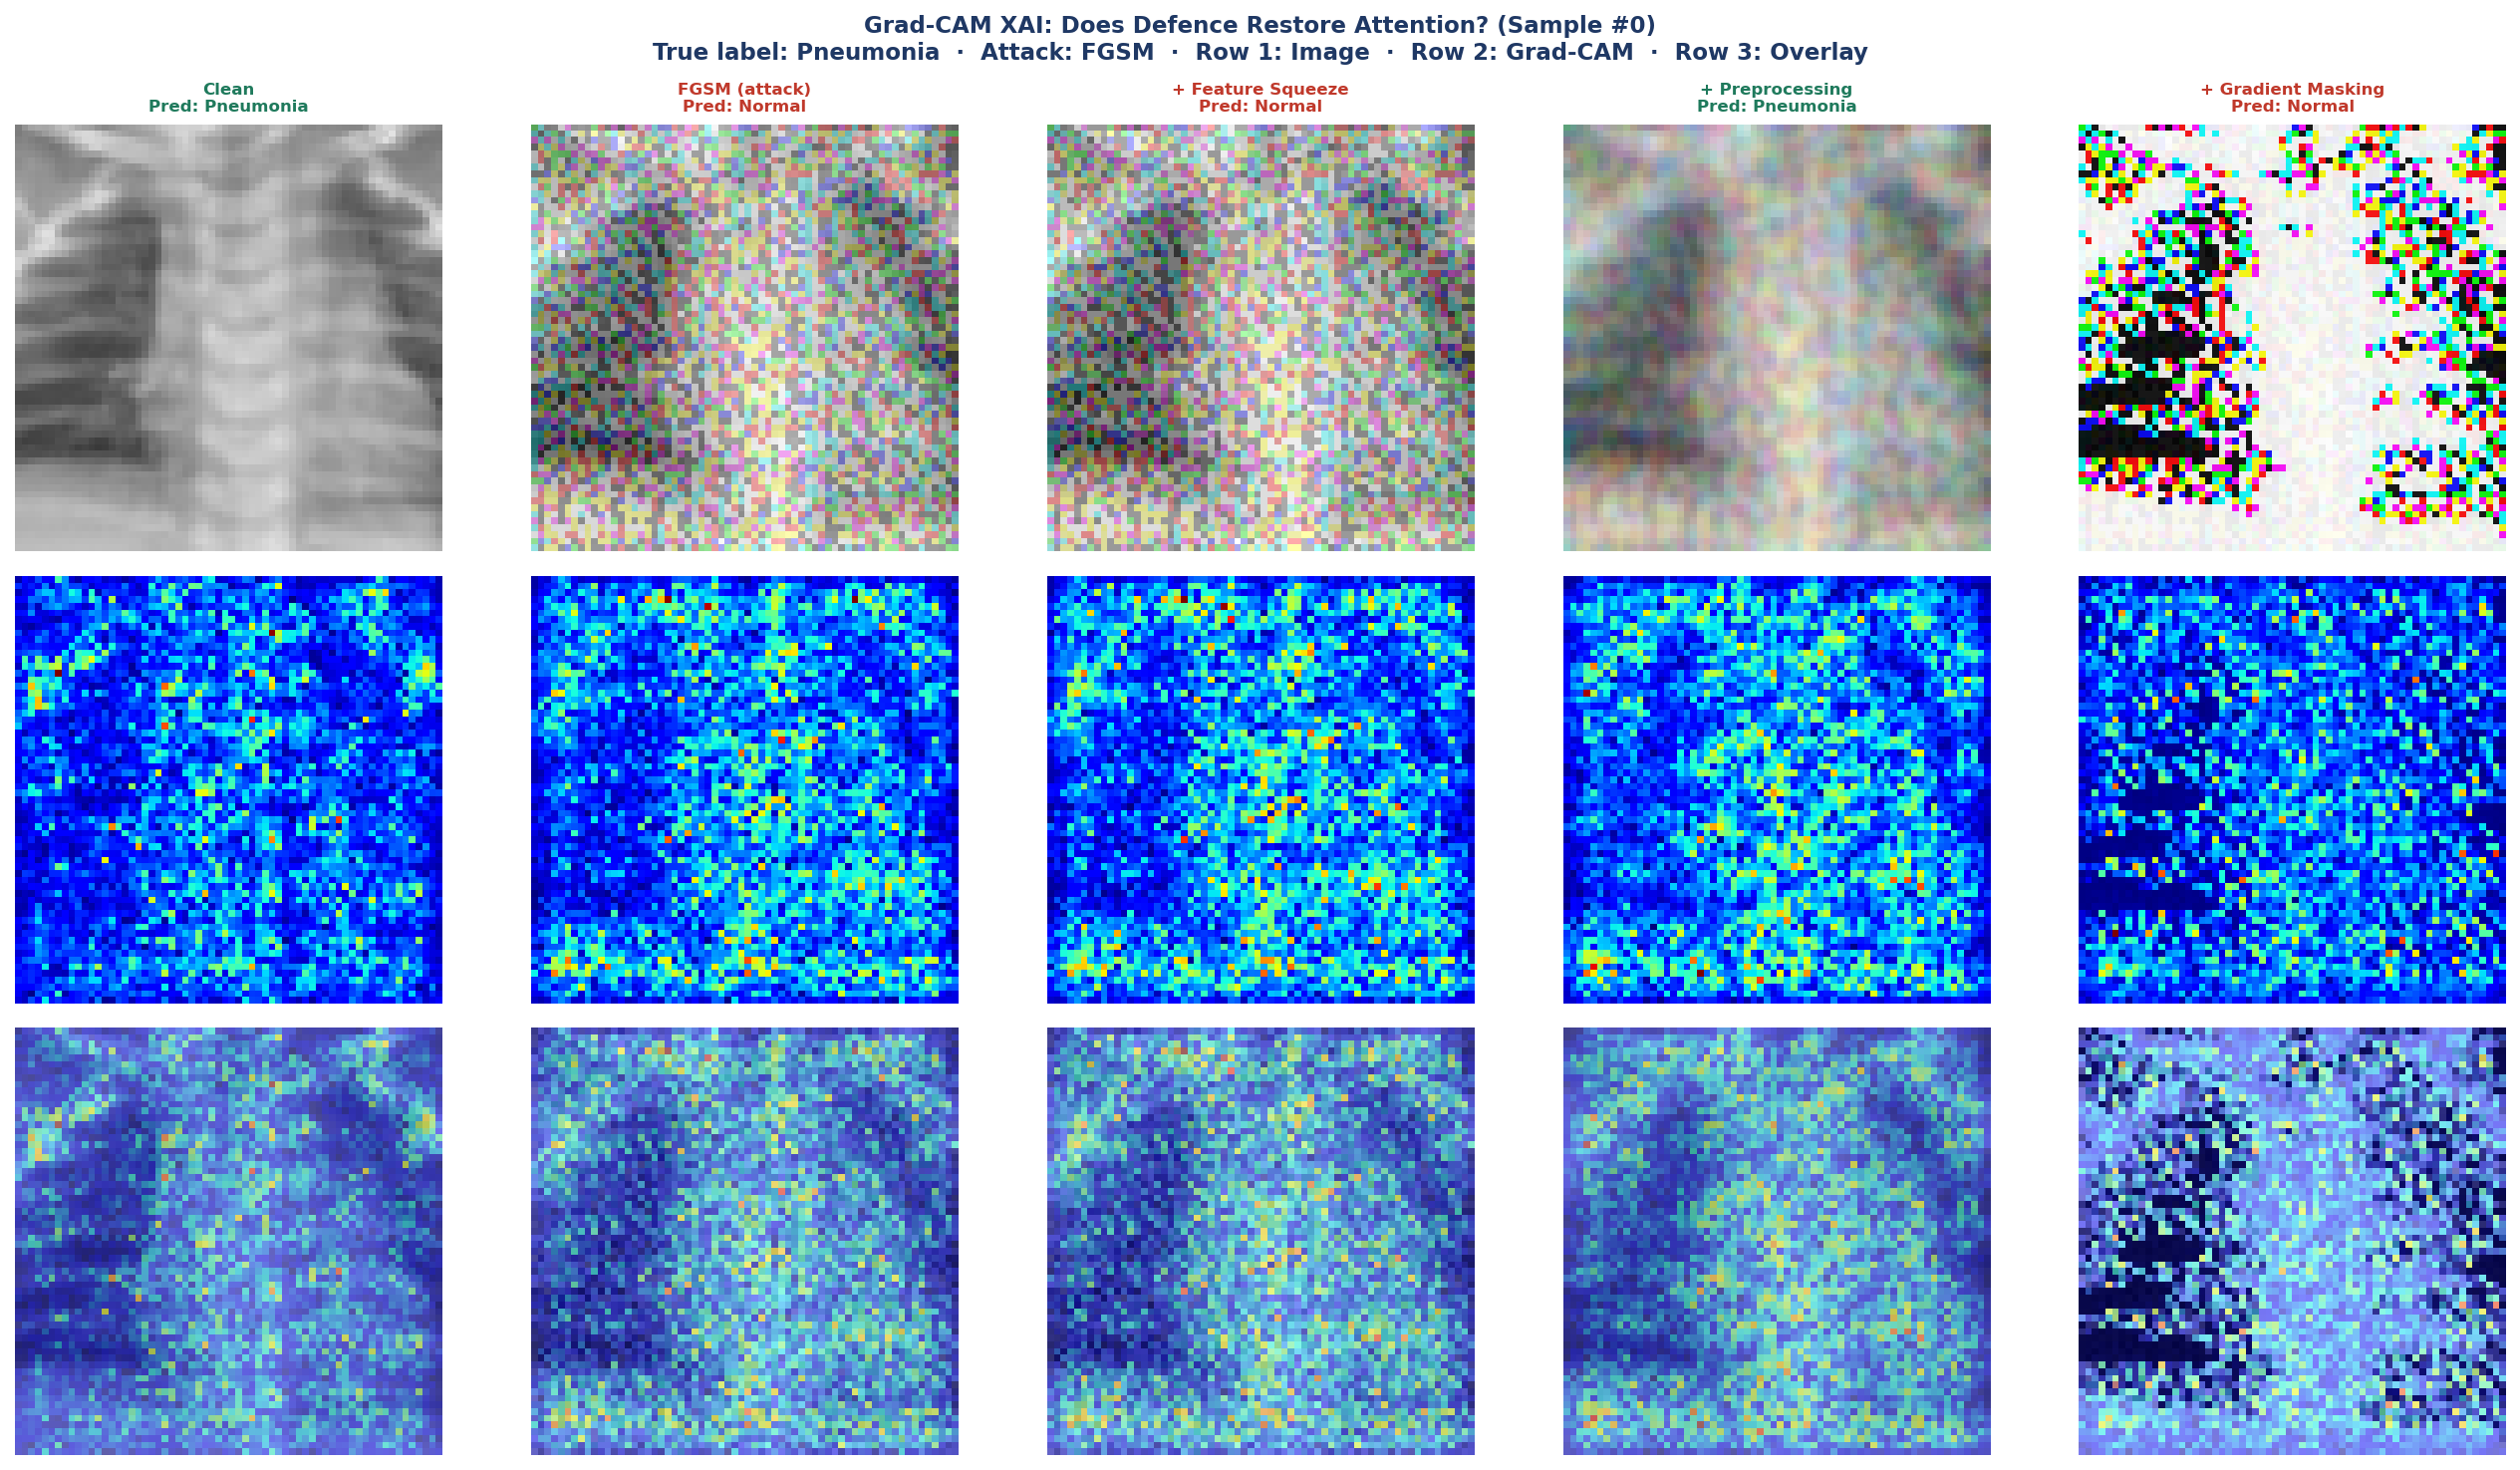


Interpretation:
  Clean   : Grad-CAM should focus on lung fields (high SSIM = 1.0 by definition)
  Attack  : attention shifts away from lungs (lower SSIM = attack detected by XAI)
  Defended: SSIM recovers toward 1.0 if defence restores correct attention
  A defence with SSIM < 0.5 is clinically unacceptable even if ASR is reduced.


In [10]:
from IPython.display import display, Image as IPImage

# ── Grad-CAM visualisation: clean vs adversarial vs defended ─────────────────
# For the SAMPLE image (first pneumonia case): compare Grad-CAM attention
# under clean, FGSM attack, and each of the four defences applied to FGSM.
# This directly answers the S4 question: does defence restore attention?
#
# Row 1: original image
# Row 2: Grad-CAM heatmap  (jet colourmap)
# Row 3: heatmap overlaid on image

# Build the five conditions to compare
first_attack_name = list(attack_results.keys())[0]  # FGSM (first in dict)
adv_sample = attack_results[first_attack_name]['adv'][SAMPLE]

gradcam_conditions = [
    ('Clean',                      X_attack[SAMPLE]),
    (f'{first_attack_name} (attack)',  adv_sample),
    ('+ Feature Squeeze',          feature_squeeze(adv_sample.copy())),
    ('+ Preprocessing',            preprocess_defence(adv_sample.copy())),
    ('+ Gradient Masking',         gradient_mask_defence(adv_sample.copy())),
]

print(f'Computing Grad-CAM for {len(gradcam_conditions)} conditions'
      f' (sample image #{SAMPLE}, true label: Pneumonia)...')

fig, axes = plt.subplots(3, len(gradcam_conditions),
                          figsize=(len(gradcam_conditions)*3.5, 10))
fig.suptitle(
    f'Grad-CAM XAI: Does Defence Restore Attention? (Sample #{SAMPLE})\n'
    f'True label: Pneumonia  ·  Attack: {first_attack_name}  ·'
    f'  Row 1: Image  ·  Row 2: Grad-CAM  ·  Row 3: Overlay',
    fontsize=11, fontweight='bold', color=NAVY)

for col, (label, img) in enumerate(gradcam_conditions):
    hm   = compute_gradcam(model, img, class_idx=1)
    pred = CLASS_NAMES[int(np.argmax(
        model(np.expand_dims(img, 0), training=False).numpy()))]
    ov   = overlay_gradcam(img, hm)

    # SSIM vs clean reference
    ssim_val = ssim(hm_clean_ref, hm, data_range=1.0)
    ssim_flag = '✅' if ssim_val > 0.75 else ('⚠️' if ssim_val > 0.5 else '❌')

    # Title colour: green if prediction matches true label, red if not
    t_col = GREEN if pred == 'Pneumonia' else RED

    # Row 0: original image
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(f'{label}\nPred: {pred}',
                             fontsize=8, fontweight='bold', color=t_col)
    axes[0, col].axis('off')

    # Row 1: Grad-CAM heatmap
    axes[1, col].imshow(hm, cmap='jet', vmin=0, vmax=1)
    axes[1, col].set_xlabel(f'SSIM={ssim_val:.3f} {ssim_flag}',
                              fontsize=8,
                              color=GREEN if ssim_val > 0.75 else RED,
                              fontweight='bold')
    axes[1, col].axis('off')

    # Row 2: overlay
    axes[2, col].imshow(ov)
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Image',     fontsize=9, fontweight='bold', rotation=90)
axes[1, 0].set_ylabel('Grad-CAM',  fontsize=9, fontweight='bold', rotation=90)
axes[2, 0].set_ylabel('Overlay',   fontsize=9, fontweight='bold', rotation=90)

plt.tight_layout()
plt.savefig('nb19_s4_gradcam_recovery.png', dpi=150, bbox_inches='tight')
plt.close()
display(IPImage(filename='nb19_s4_gradcam_recovery.png'))

print('\nInterpretation:')
print('  Clean   : Grad-CAM should focus on lung fields (high SSIM = 1.0 by definition)')
print('  Attack  : attention shifts away from lungs (lower SSIM = attack detected by XAI)')
print('  Defended: SSIM recovers toward 1.0 if defence restores correct attention')
print('  A defence with SSIM < 0.5 is clinically unacceptable even if ASR is reduced.')


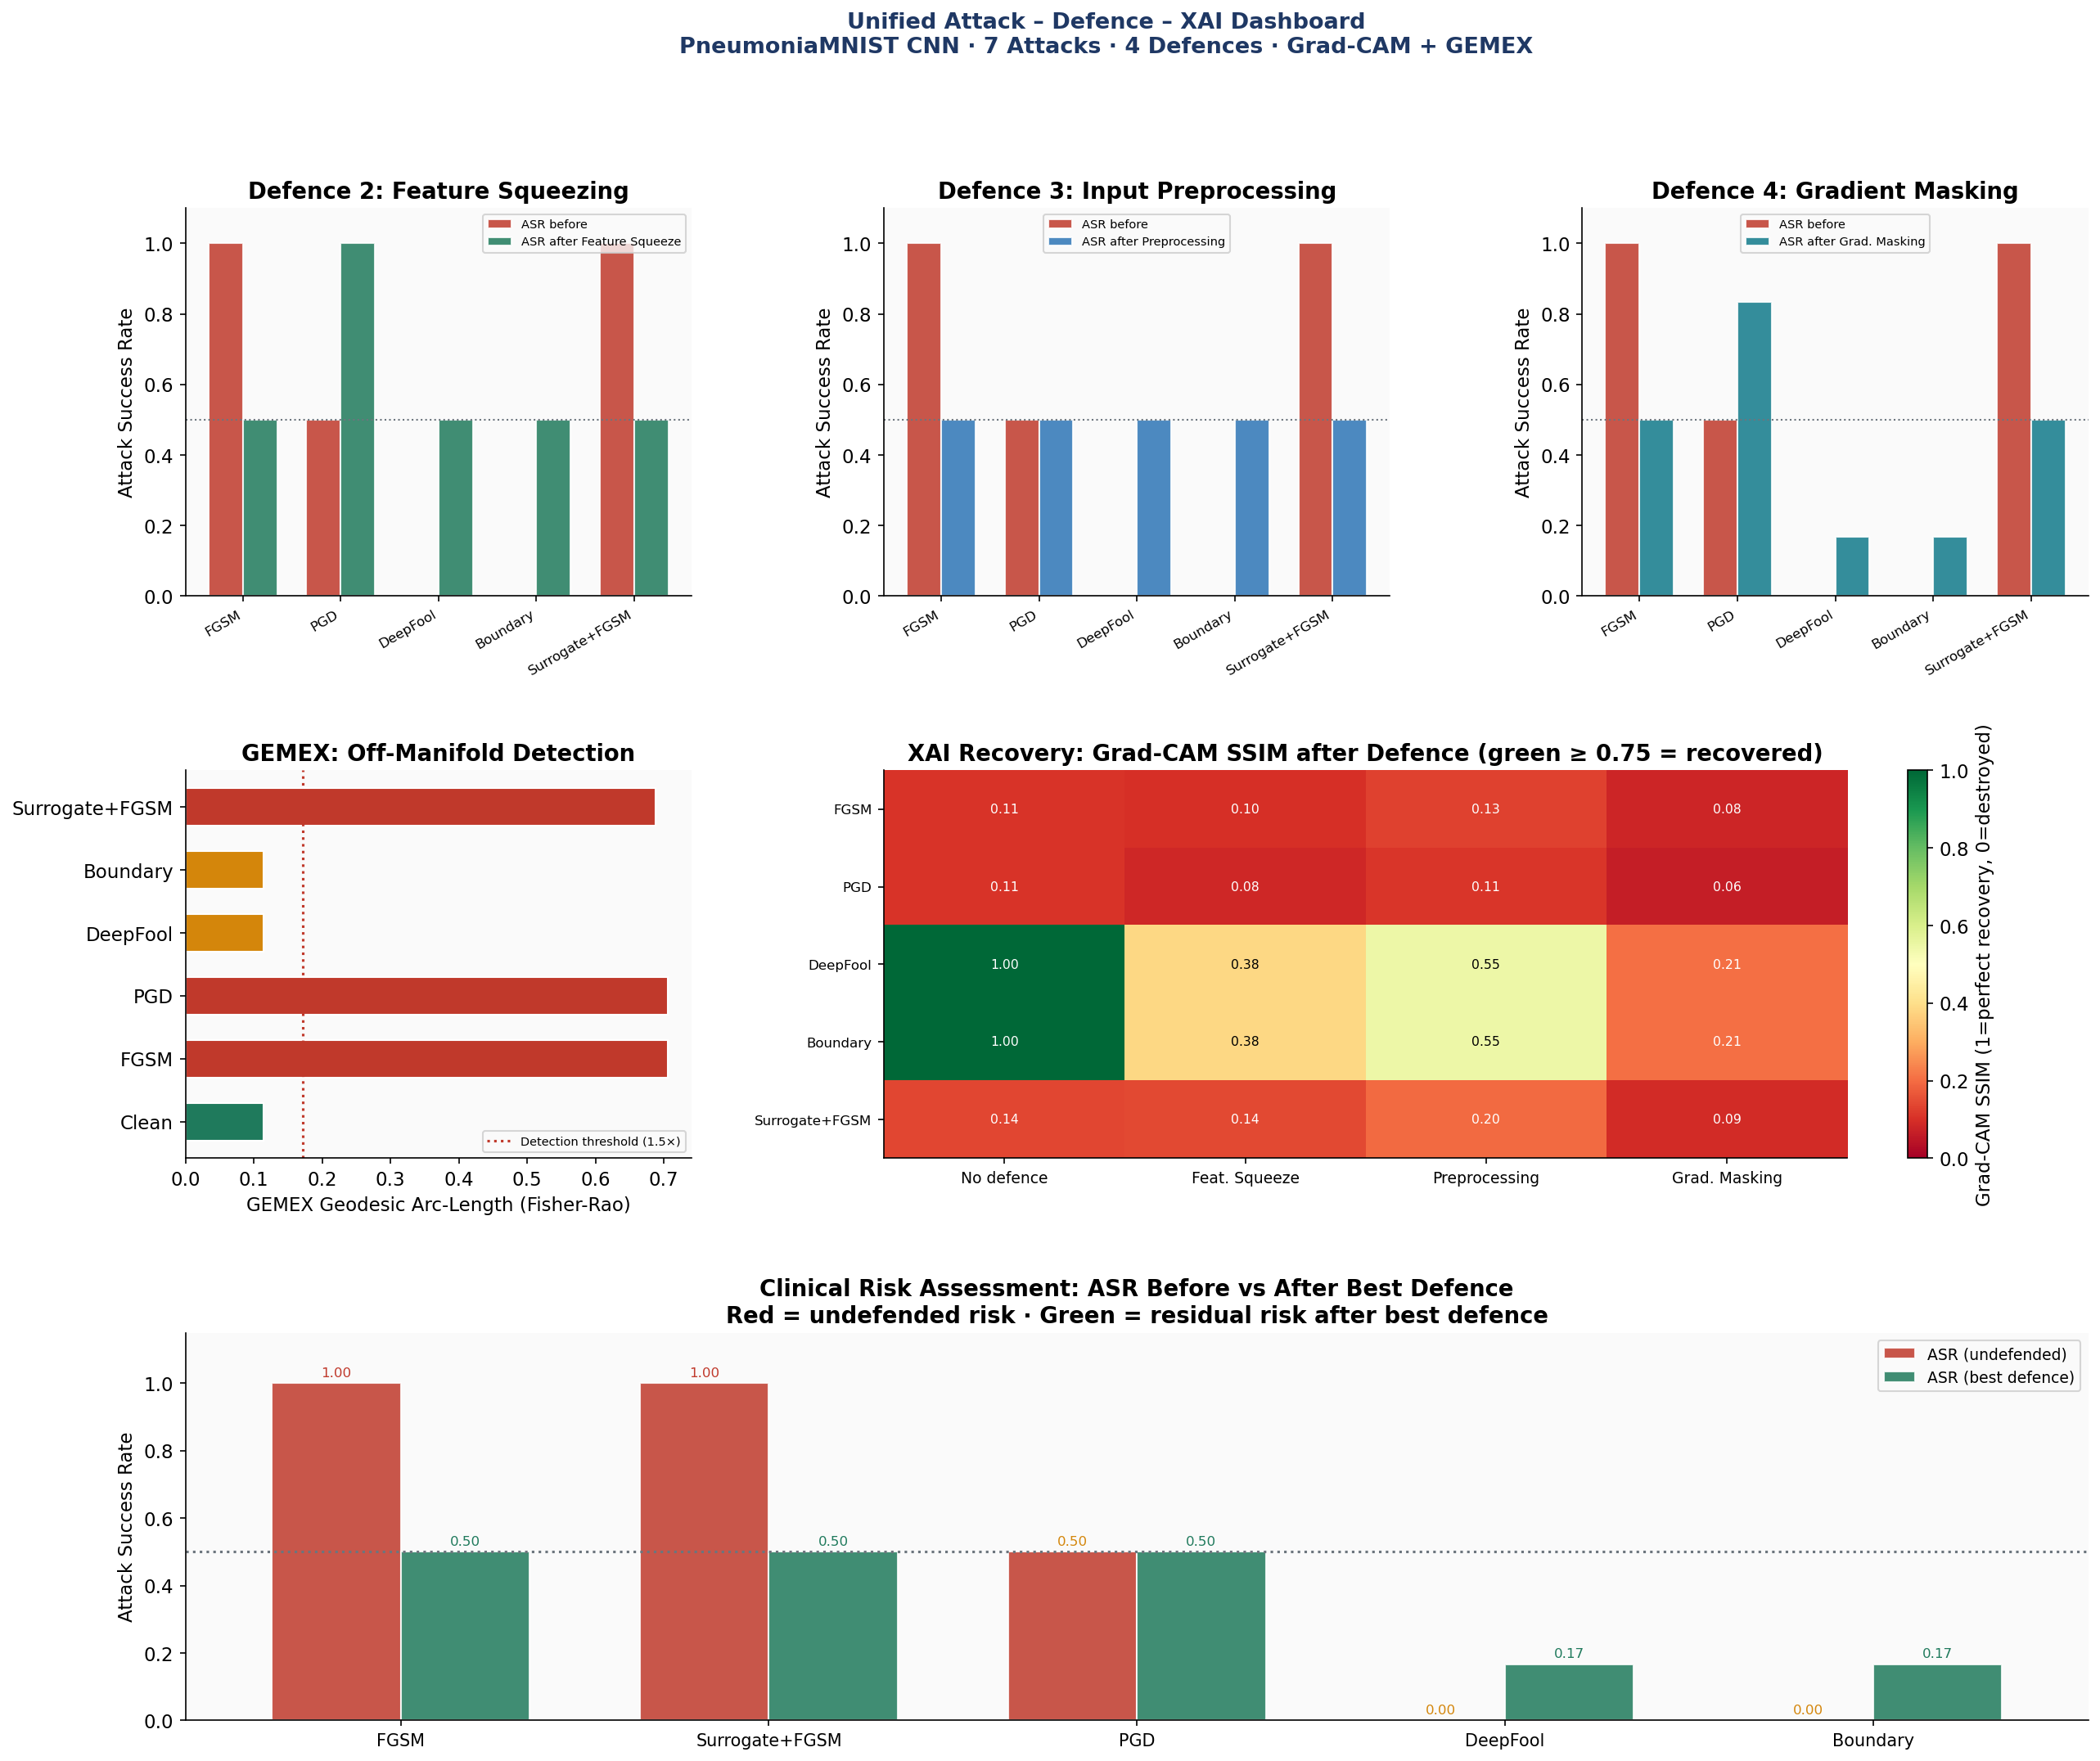

In [11]:
from IPython.display import display, Image as IPImage

# ── Unified Attack-Defence-XAI Dashboard ─────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle(
    'Unified Attack – Defence – XAI Dashboard\n'
    'PneumoniaMNIST CNN · 7 Attacks · 4 Defences · Grad-CAM + GEMEX',
    fontsize=13, fontweight='bold', color=NAVY, y=0.98)

short_atk = [n.split(' ')[0] for n in attack_results.keys()]

# Panel 1: ASR before/after feature squeezing
ax1 = fig.add_subplot(gs[0,0])
asr_before = [attack_results[n]['asr']  for n in attack_results]
asr_sq_after= [squeeze_results[n]['asr'] for n in attack_results]
x = np.arange(len(short_atk))
w = 0.35
ax1.bar(x-w/2, asr_before, w, color=RED,  label='ASR before', alpha=0.85, edgecolor='white')
ax1.bar(x+w/2, asr_sq_after, w, color=GREEN, label='ASR after Feature Squeeze', alpha=0.85, edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(short_atk, rotation=30, ha='right', fontsize=8)
ax1.set_ylabel('Attack Success Rate'); ax1.set_ylim(0,1.1)
ax1.set_title('Defence 2: Feature Squeezing', fontweight='bold')
ax1.legend(fontsize=7); ax1.axhline(0.5, color=GREY, ls=':', lw=1)

# Panel 2: ASR before/after preprocessing
ax2 = fig.add_subplot(gs[0,1])
asr_pp_after = [preproc_results[n]['asr'] for n in attack_results]
ax2.bar(x-w/2, asr_before, w, color=RED,  label='ASR before', alpha=0.85, edgecolor='white')
ax2.bar(x+w/2, asr_pp_after, w, color=BLUE, label='ASR after Preprocessing', alpha=0.85, edgecolor='white')
ax2.set_xticks(x); ax2.set_xticklabels(short_atk, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Attack Success Rate'); ax2.set_ylim(0,1.1)
ax2.set_title('Defence 3: Input Preprocessing', fontweight='bold')
ax2.legend(fontsize=7); ax2.axhline(0.5, color=GREY, ls=':', lw=1)

# Panel 3: ASR before/after gradient masking
ax3 = fig.add_subplot(gs[0,2])
asr_gm_after = [gradmask_results[n]['asr'] for n in attack_results]
ax3.bar(x-w/2, asr_before, w, color=RED,  label='ASR before', alpha=0.85, edgecolor='white')
ax3.bar(x+w/2, asr_gm_after, w, color=TEAL, label='ASR after Grad. Masking', alpha=0.85, edgecolor='white')
ax3.set_xticks(x); ax3.set_xticklabels(short_atk, rotation=30, ha='right', fontsize=8)
ax3.set_ylabel('Attack Success Rate'); ax3.set_ylim(0,1.1)
ax3.set_title('Defence 4: Gradient Masking', fontweight='bold')
ax3.legend(fontsize=7); ax3.axhline(0.5, color=GREY, ls=':', lw=1)

# Panel 4: GEMEX geodesic arc-length comparison
ax4 = fig.add_subplot(gs[1,0])
geo_means = [np.mean(geo_results[n]['arc']) if n in geo_results else 0
              for n in (['Clean'] + list(attack_results.keys()))]
geo_cols  = [GREEN] + [RED if m > geo_means[0]*1.5 else ORANGE for m in geo_means[1:]]
ax4.barh(['Clean'] + short_atk, geo_means, color=geo_cols, edgecolor='white', height=0.6)
ax4.axvline(geo_means[0]*1.5, color=RED, ls=':', lw=1.5, label='Detection threshold (1.5×)')
ax4.set_xlabel('GEMEX Geodesic Arc-Length (Fisher-Rao)')
ax4.set_title('GEMEX: Off-Manifold Detection', fontweight='bold')
ax4.legend(fontsize=7)

# Panel 5: Grad-CAM SSIM heatmap
ax5 = fig.add_subplot(gs[1,1:3])
ssim_mat = np.array([[r[1],r[2],r[3],r[4]] for r in ssim_table])
im = ax5.imshow(ssim_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax5.set_xticks([0,1,2,3])
ax5.set_xticklabels(['No defence','Feat. Squeeze','Preprocessing','Grad. Masking'], fontsize=9)
ax5.set_yticks(range(len(ssim_table)))
ax5.set_yticklabels([r[0] for r in ssim_table], fontsize=8)
plt.colorbar(im, ax=ax5, label='Grad-CAM SSIM (1=perfect recovery, 0=destroyed)')
for i in range(len(ssim_table)):
    for j in range(4):
        ax5.text(j,i,f'{ssim_mat[i,j]:.2f}',ha='center',va='center',fontsize=7.5,
                  color='black' if 0.3<ssim_mat[i,j]<0.8 else 'white')
ax5.set_title('XAI Recovery: Grad-CAM SSIM after Defence (green ≥ 0.75 = recovered)',
               fontweight='bold')

# Panel 6: Clinical risk assessment
ax6 = fig.add_subplot(gs[2,:])
risk_data = []
for name, r in attack_results.items():
    short = name.split(' ')[0]
    best_defence_asr = min(
        squeeze_results[name]['asr'],
        preproc_results[name]['asr'],
        gradmask_results[name]['asr'])
    risk_data.append((short, r['asr'], best_defence_asr, r['l2']))
risk_data.sort(key=lambda x: x[1], reverse=True)
rnames  = [r[0] for r in risk_data]
x = np.arange(len(rnames))
ax6.bar(x-w/2, [r[1] for r in risk_data], w, color=RED,   label='ASR (undefended)', alpha=0.85, edgecolor='white')
ax6.bar(x+w/2, [r[2] for r in risk_data], w, color=GREEN, label='ASR (best defence)',  alpha=0.85, edgecolor='white')
ax6.set_xticks(x); ax6.set_xticklabels(rnames, fontsize=10)
ax6.set_ylabel('Attack Success Rate'); ax6.set_ylim(0,1.15)
ax6.set_title('Clinical Risk Assessment: ASR Before vs After Best Defence\n'
               'Red = undefended risk · Green = residual risk after best defence',
               fontweight='bold')
ax6.legend(fontsize=9); ax6.axhline(0.5, color=GREY, ls=':', lw=1.5)

for i, r in enumerate(risk_data):
    colour = RED if r[1]>0.5 else ORANGE
    ax6.text(i-w/2, r[1]+0.02, f'{r[1]:.2f}', ha='center', fontsize=8, color=colour)
    ax6.text(i+w/2, r[2]+0.02, f'{r[2]:.2f}', ha='center', fontsize=8, color=GREEN)

plt.savefig('nb19_s4_dashboard.png', dpi=150, bbox_inches='tight')
plt.close()
display(IPImage(filename='nb19_s4_dashboard.png'))

---
## Summary

| Section | Content | Key deliverable |
|---------|---------|----------------|
| S1 | Shared setup (NB18 pipeline reproduced) | Self-contained: runs without NB18 |
| S2 | GEMEX geodesic + image_trio | Arc-length on CNN embeddings (numpy head, fast); GeodesicCAM per attack |
| S3 | 4 defences (Adv. Training, Feature Squeeze, Preprocessing, Grad. Masking) | ASR reduction per defence |
| S4 | XAI recovery dashboard | Grad-CAM SSIM + clinical risk matrix |

**Key clinical insight:**
XAI (Grad-CAM + GEMEX) is not merely an interpretability tool — it is an **attack detector**.
GEMEX geodesic distance provides a label-free, real-time signal that an adversarial
image is off-manifold. Grad-CAM SSIM quantifies whether a defence restores interpretability.
A defence that reduces ASR but destroys XAI attention is clinically unacceptable.

**NB18 → NB19 flow:**
NB18 establishes the attack surface (7 attacks, Grad-CAM shifts).
NB19 provides the defence and detection layer (GEMEX + 4 defences + recovery audit).

### References
- Cohen, J. et al. (2019). Certified adversarial robustness via randomised smoothing. *ICML 2019*.
- Kermany, D. S. et al. (2018). Identifying medical diagnoses by deep learning. *Cell 172*(5).
- Madry, A. et al. (2018). Towards deep learning models resistant to adversarial attacks. *ICLR 2018*.
- Page, E. S. (1954). Continuous inspection schemes. *Biometrika, 41*(1–2), 100–115.
- Selvaraju, R. R. et al. (2017). Grad-CAM. *ICCV 2017*, 618–626.
- Xu, W. et al. (2018). Feature squeezing. *NDSS 2018*.
- Yang, J. et al. (2023). MedMNIST v2. *Scientific Data 10*, 428.